<a href="https://colab.research.google.com/github/xr-cc/DSCoV-Workshop-on-Topic-Modeling/blob/main/topic_modeling_scRNAseq_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic Modeling Demo 2 (scRNA-seq)
In this notebook, we will see how topic modeling methods LDA and NMF can be applied onto a real-word single-cell RNA sequencing (scRNA-seq) dataset.

The dataset is downloaded from [PBMC from a healthy donor - granulocytes removed through cell sorting (10k)](https://support.10xgenomics.com/single-cell-multiome-atac-gex/datasets/1.0.0/pbmc_granulocyte_sorted_10k) from 10x Genomics, which contains cryopreserved human peripheral blood mononuclear cells (**PBMCs**) of a healthy female donor aged 25.

> The data file stores gene expression counts per cell after quality filtering has been applied. Each value in the matrix is the number of unique RNA molecules (UMIs) detected for a given gene in a given cell.

The Python package `Scanpy` will be used to load and process the data.

**Reference**

10x Genomics. 2020. PBMC from a healthy donor – granulocytes removed through cell sorting (10k); Single Cell Multiome ATAC + Gene Expression (Cell Ranger ARC v1.0.0) [Data set]. 10x Genomics.


Install package `scanpy` for single cell data processing.

In [1]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.3/169.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 3.3 MB/s eta 0:00:00


Import packages

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors

import scanpy as sc
from sklearn.decomposition import LatentDirichletAllocation, NMF



## Load data

In [16]:
# from google.colab import drive
# # Mount Google Drive
# drive.mount('/content/drive')
# Load the HDF5 file from Google Drive (e.g., pbmc_granulocyte_sorted_10k data)
# file_path = '/content/drive/MyDrive/DSCoV_Workshop/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5' # Update the path if needed
# adata = sc.read_10x_h5(file_path)


# load 10x PBMC 3k dataset (processed) from Scanpy directly
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [17]:
# Filter out low-quality genes and cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'

In [18]:
# annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)
# remove cells that have too many mitochondrial genes expressed or too many total counts:
adata = adata[
    (adata.obs.n_genes_by_counts < 2500) & (adata.obs.n_genes_by_counts > 200) & (adata.obs.pct_counts_mt < 5),
    :,
].copy()
adata.layers["counts"] = adata.X.copy()
adata


AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    layers: 'counts'

In [19]:
# Normalize total counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the data
sc.pp.log1p(adata)

# Select highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
adata = adata[:, adata.var.highly_variable]

adata

View of AnnData object with n_obs × n_vars = 2638 × 2000
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'

In [20]:
# Extract data matrix
X = adata.X
print(X.shape)

df = pd.DataFrame(
    adata.X.toarray(),        # convert sparse to dense
    index=adata.obs_names,    # cells
    columns=adata.var_names   # genes
)

(2638, 2000)


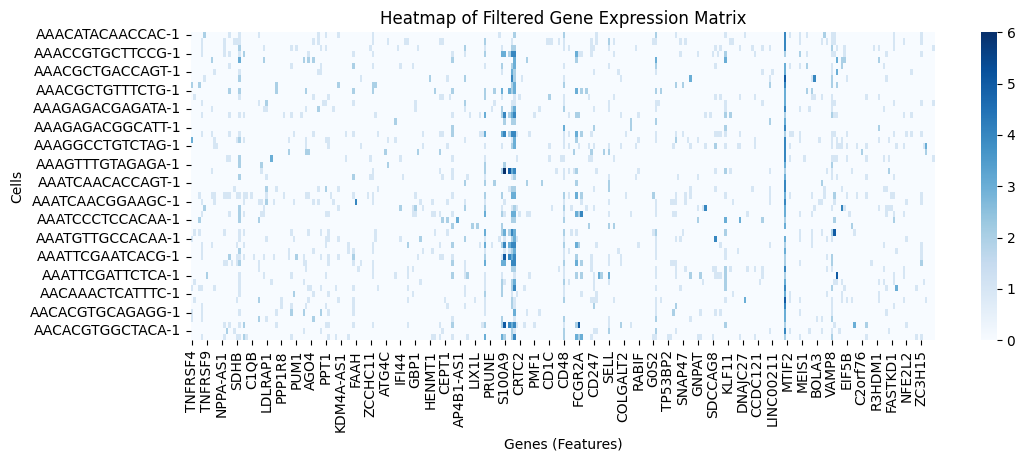

In [21]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.iloc[0:50][df.columns[:300]].astype(int), cmap='Blues') # You can choose a different colormap
plt.title('Heatmap of Filtered Gene Expression Matrix')
plt.xlabel('Genes (Features)')
plt.ylabel('Cells')
plt.show()

## Perform dimensionality reduction to visualize cells

In [23]:
# Perform principal component analysis
sc.pp.pca(adata)
# Compute the neighborhood graph
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
# Embed the graph in two dimensions using UMAP
sc.tl.umap(adata)

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


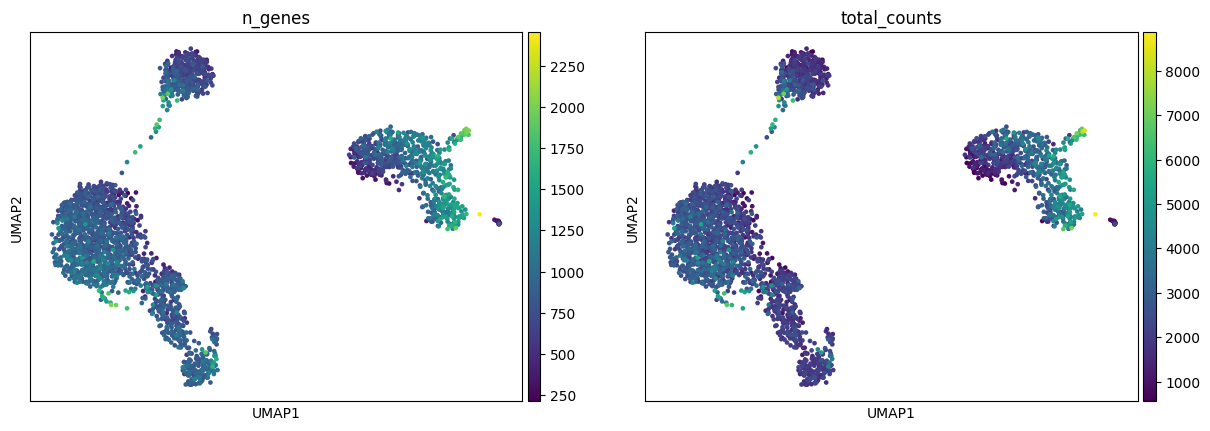

In [24]:
sc.pl.umap(adata, color=['n_genes','total_counts'])

## Perform topic modeling via LDA

In [25]:
# Define the number of latent cell types
n_topics = 5

# Create an LDA model
lda = LatentDirichletAllocation(n_components=n_topics, random_state=0)

# Fit the model to the filtered gene expression matrix
lda.fit(X)

# Get the cell-type distribution for each cell
Phi = lda.transform(X)

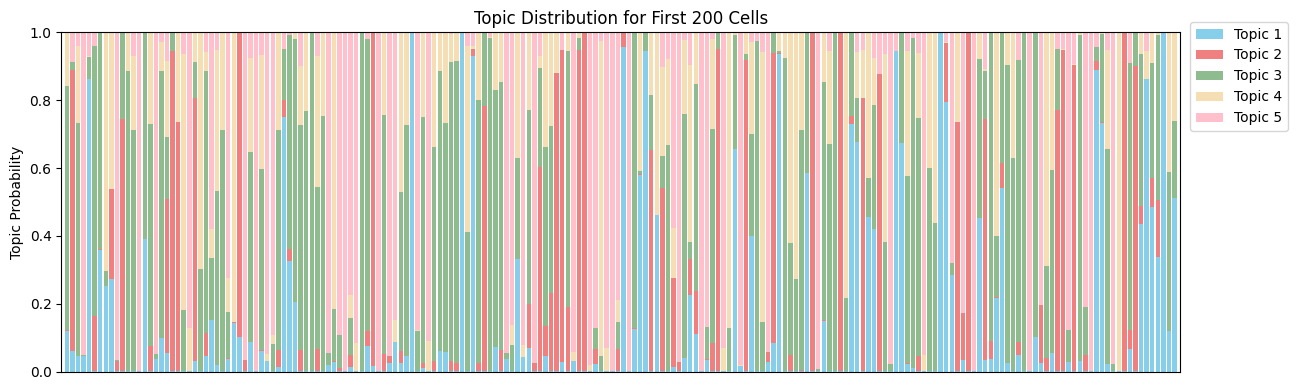

In [26]:
# Define colors for each topic
colors = ['skyblue', 'lightcoral', 'darkseagreen', 'wheat', 'pink', 'orange', 'brown', 'purple', 'gray', 'olive']

# Plot the stacked bar charts for document-topic vectors for first 1000 cells
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 4)) # Adjust figure size as needed
for i in range(200):
    topic_probabilities = Phi[i]
    bottom = 0
    for topic_idx, prob in enumerate(topic_probabilities):
        ax.bar(i, prob, bottom=bottom, color=colors[topic_idx % len(colors)], label=f'Topic {topic_idx+1}' if i == 0 else "") # Add label only for the first bar
        bottom += prob

ax.set_xticks([])
ax.set_xlim(-1, 200)
ax.set_ylabel('Topic Probability')
ax.set_ylim(0, 1)
ax.set_title('Topic Distribution for First 200 Cells')
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles[:n_topics], labels[:n_topics], loc='upper left', bbox_to_anchor=(0.99, 0.95))
plt.tight_layout()
plt.show()

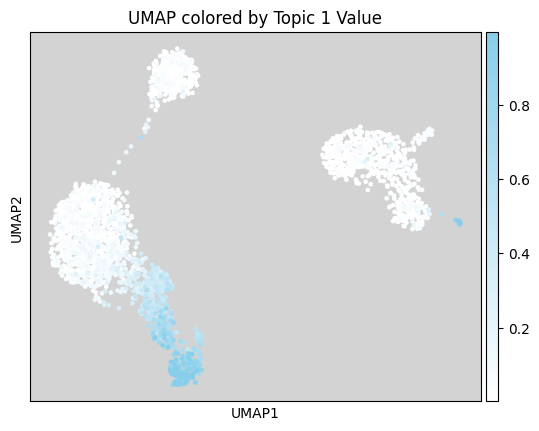

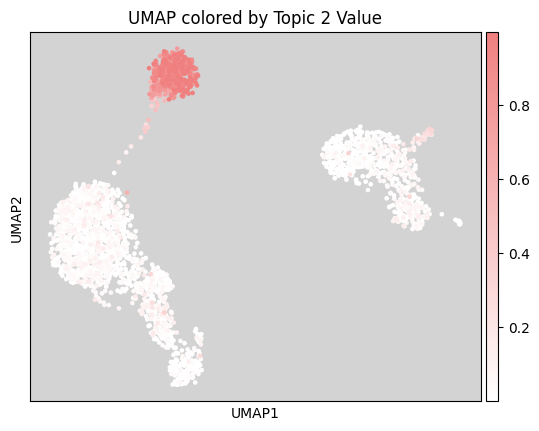

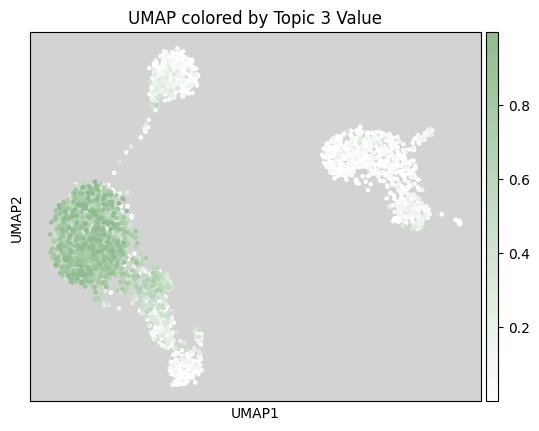

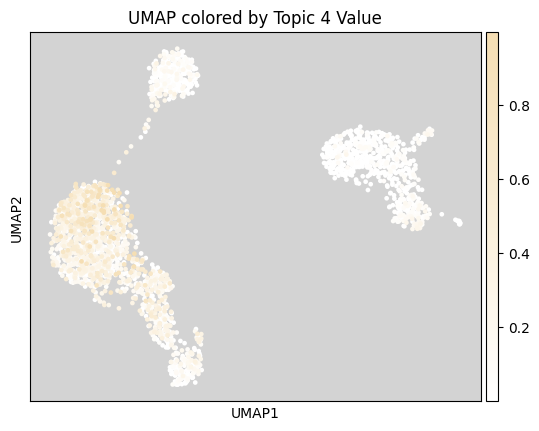

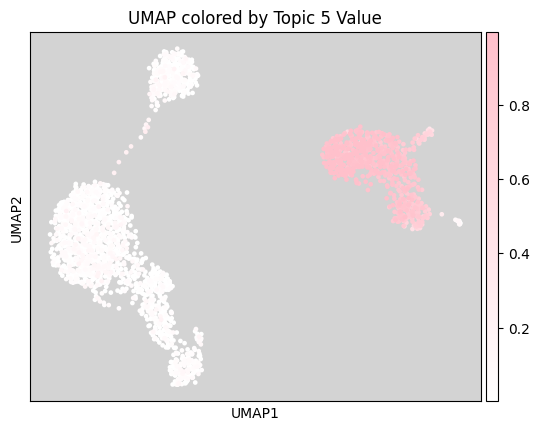

In [27]:
# Define the base colors for each topic
base_colors = ['skyblue', 'lightcoral', 'darkseagreen', 'wheat', 'pink']

for topic_idx in range(n_topics):
  # Add per-topic values to adata.obs
  adata.obs['topic_{}_value'.format(topic_idx+1)] = Phi[:, topic_idx]

  # Create a gradient colormap for the current topic
  base_color = base_colors[topic_idx % len(base_colors)]
  colors = [(1, 1, 1), matplotlib.colors.to_rgb(base_color)] # White to base color
  cmap = matplotlib.colors.LinearSegmentedColormap.from_list("white_to_{}".format(base_color), colors)

  # Plot cells in UMAP space colored by the per-topic value
  sc.pl.umap(adata, color='topic_{}_value'.format(topic_idx+1), title='UMAP colored by Topic {} Value'.format(topic_idx+1), cmap=cmap, show=False)
  plt.gca().set_facecolor('lightgray')
  plt.show()